# Test of the Reciever Simulator


In [6]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

s11_termination [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1

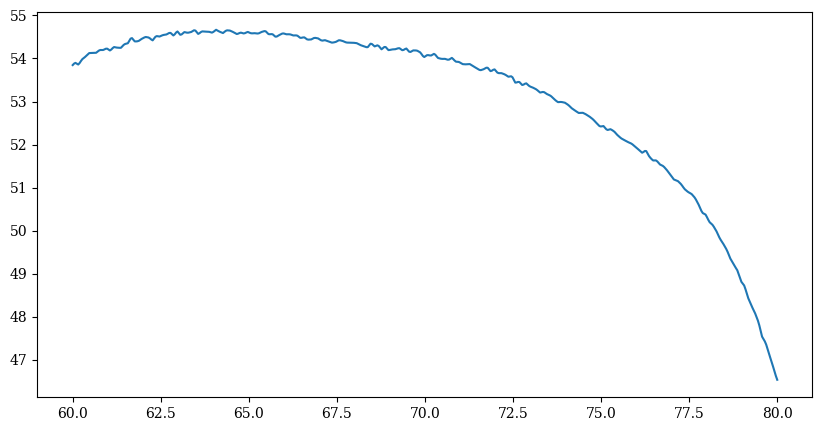

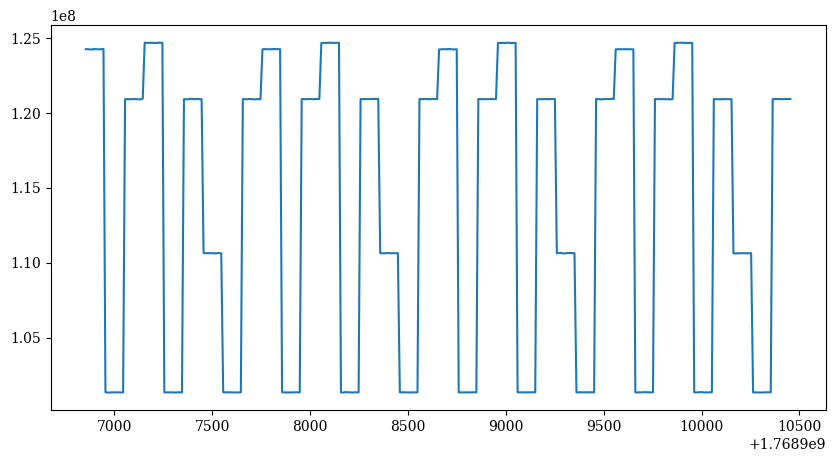

In [7]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 512))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273-60,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+100,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


observation_handler_obj = ObservationHandler(observation_length=1*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[#long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=10*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=1,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=1,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=1)







plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.show()

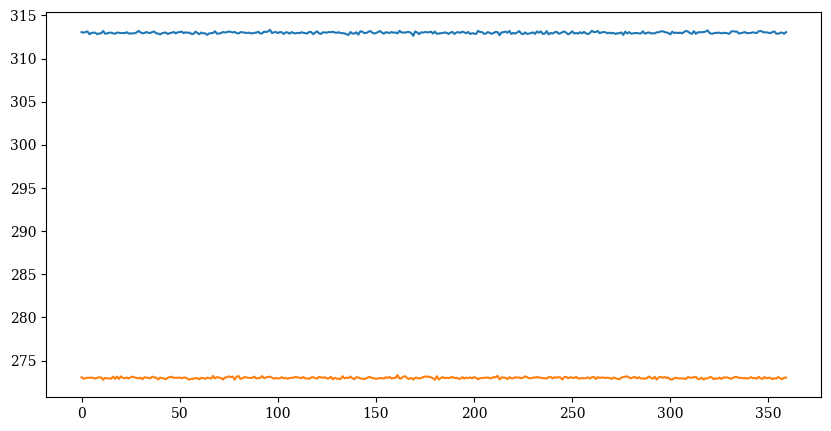

In [8]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [9]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


In [10]:
print(final_states)

[np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_short'), np.str_('open'), np.str_('short')]


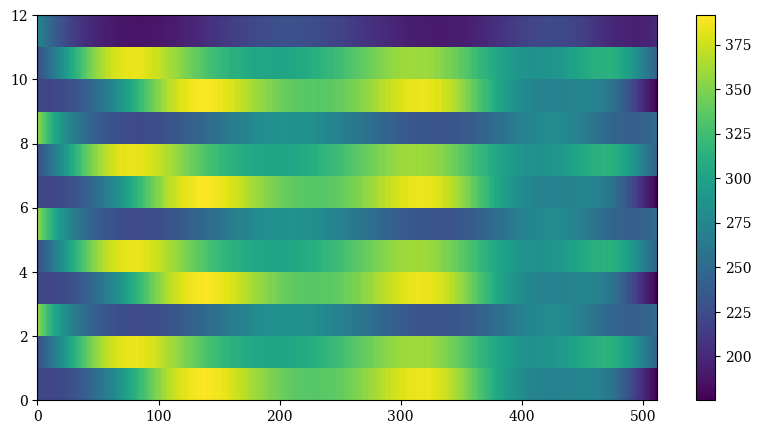

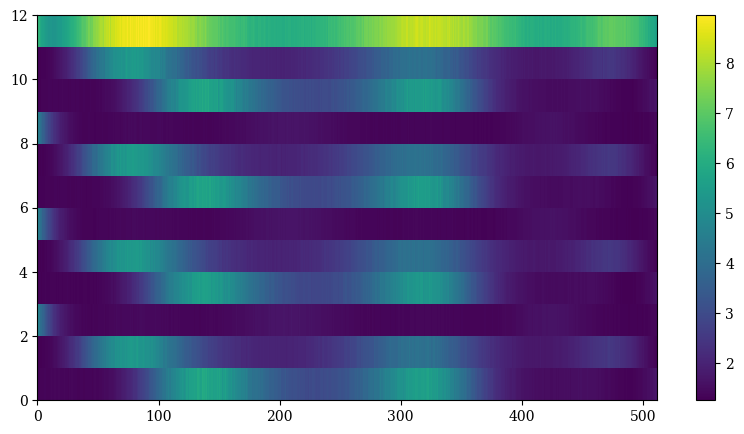

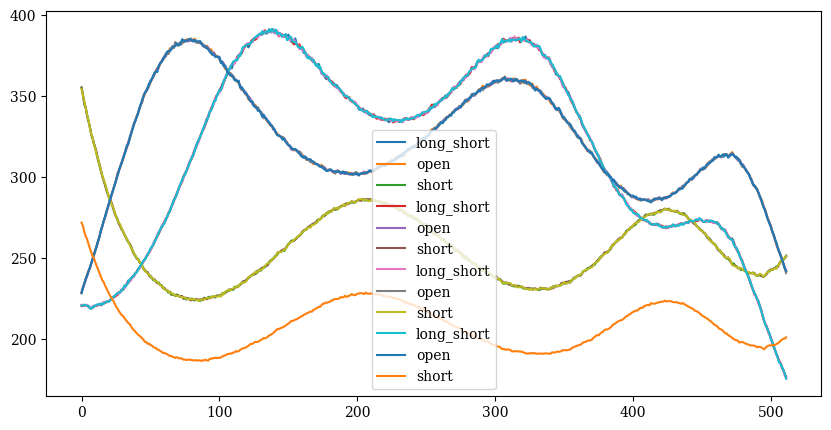

In [11]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()

In [ ]:
transfer_matrix = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=(10,1),
                                            cos_poly_orders=(10,1),
                                            sin_poly_orders=(10,1),
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec)

TypeError: Unsupported operand type(s) for ufunc subtract: 'ndarray,Quantity'

In [ ]:
#FIXME
"""Fix switch state string"""

'Fix switch state string'